In [ ]:
import glob
import torch
import gc
import re
import os
from os.path import exists
import pickle
import tqdm

import scanpy as sc
import cell2fate as c2f
import numpy as np
import pandas as pd
import torch

import matplotlib.pyplot as plt
import matplotlib
import matplotlib as mpl
from matplotlib.patches import ConnectionPatch
import seaborn as sns
import matplotlib.colors as mcolors

from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import cophenet
from scipy.stats import spearmanr
from scipy.stats import rankdata
from itertools import product
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics import silhouette_score
from sklearn.metrics import pairwise_distances
from sklearn.cluster import AgglomerativeClustering
from itertools import combinations

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

palette_25 = [
    "#1f77b4",  # blue
    "#ff7f0e",  # orange
    "#2ca02c",  # green
    "#d62728",  # red
    "#9467bd",  # purple
    "#8c564b",  # brown
    "#e377c2",  # pink
    "#7f7f7f",  # gray
    "#bcbd22",  # olive
    "#17becf",  # cyan
    "#003f5c",  # dark blue
    "#ffa600",  # amber
    "#2f4b7c",  # indigo
    "#a05195",  # magenta
    "#665191",  # violet
    "#d45087",  # rose
    "#f95d6a",  # coral
    "#00cc99",  # teal-green

    # --- added colors ---
    "#66c2a5",  # mint
    "#fc8d62",  # peach
    "#8da0cb",  # lavender-blue
    "#e78ac3",  # light pink
    "#a6d854",  # lime
    "#ffd92f",  # yellow
    "#e5c494",  # sand
]

from matplotlib.colors import ListedColormap
cmap25 = ListedColormap(palette_25, name="distinct25")

Global seed set to 0


In [ ]:
def mu_alpha(alpha_new, alpha_old, tau, lam):
    '''Calculates transcription rate as a function of new target transcription rate,
    old transcription rate at changepoint, time since change point and rate of exponential change process'''
    return (alpha_new - alpha_old) * (1 - torch.exp(-lam*tau)) + alpha_old

def mu_mRNA_continuousAlpha_withPlates(alpha, beta, gamma, tau, u0, s0, delta_alpha, lam):
    ''' Calculates expected value of spliced and unspliced counts as a function of rates, latent time, initial states,
    difference to transcription rate in previous state and rate of exponential change process between states.'''

    mu_u = u0*torch.exp(-beta*tau) + (alpha/beta)* (1 - torch.exp(-beta*tau)) + delta_alpha/(beta-lam+10**(-5))*(torch.exp(-beta*tau) - torch.exp(-lam*tau))
    mu_s = (s0*torch.exp(-gamma*tau) +
    alpha/gamma * (1 - torch.exp(-gamma*tau)) +
    (alpha - beta * u0)/(gamma - beta+10**(-5)) * (torch.exp(-gamma*tau) - torch.exp(-beta*tau)) +
    (delta_alpha*beta)/((beta - lam+10**(-5))*(gamma - beta+10**(-5))) * (torch.exp(-beta*tau) - torch.exp(-gamma*tau))-
    (delta_alpha*beta)/((beta - lam+10**(-5))*(gamma - lam+10**(-5))) * (torch.exp(-lam*tau) - torch.exp(-gamma*tau)))

    return torch.stack([mu_u, mu_s], axis = -1)

def mu_mRNA_continousAlpha_globalTime_twoStates(alpha_ON, alpha_OFF, beta, gamma, lam_gi, T_c, T_gON, T_gOFF, Zeros):
    '''Calculates expected value of spliced and unspliced counts as a function of rates,
    global latent time, initial states and global switch times between two states'''
    n_cells = T_c.shape[-2]
    n_genes = alpha_ON.shape[-1]
    tau = torch.clip(T_c - T_gON, min = 10**(-5))
    t0 = T_gOFF - T_gON
    # Transcription rate in each cell for each gene:
    boolean = (tau < t0).reshape(n_cells, 1)
    alpha_cg = alpha_ON*boolean + alpha_OFF*~boolean
    # Time since changepoint for each cell and gene:
    tau_cg = tau*boolean + (tau - t0)*~boolean
    # Initial condition for each cell and gene:
    lam_g = ~boolean*lam_gi[:,1] + boolean*lam_gi[:,0]
    initial_state = mu_mRNA_continuousAlpha_withPlates(alpha_ON, beta, gamma, t0,
                                                       Zeros, Zeros, alpha_ON-alpha_OFF, lam_gi[:,0])
    initial_alpha = mu_alpha(alpha_ON, alpha_OFF, t0, lam_gi[:,0])
    u0_g = 10**(-5) + ~boolean*initial_state[:,:,0]
    s0_g = 10**(-5) + ~boolean*initial_state[:,:,1]
    delta_alpha = ~boolean*initial_alpha*(-1) + boolean*alpha_ON*(1)
    alpha_0 = alpha_OFF + ~boolean*initial_alpha
    # Unspliced and spliced count variance for each gene in each cell:
    mu_RNAvelocity = torch.clip(mu_mRNA_continuousAlpha_withPlates(alpha_cg, beta, gamma, tau_cg,
                                                         u0_g, s0_g, delta_alpha, lam_g), min = 10**(-5))
    alpha_0 = alpha_OFF + ~boolean*initial_alpha
    alpha_cg = mu_alpha(alpha_cg, alpha_0, tau_cg, lam_g)
    return mu_RNAvelocity, alpha_cg

def listed_cmap_from_hex(hex_color, n=256, min_color="white"):
    start = np.array(mcolors.to_rgb(min_color))
    end = np.array(mcolors.to_rgb(hex_color))

    colors = [
        start + (end - start) * i / (n - 1)
        for i in range(n)
    ]

    return mcolors.ListedColormap(colors)

In [ ]:
data_dir = '../data/GBM/'
clone_dir = '../data/GBM/clones/'
save_dir = '../data/cell2fate/'
patients = np.array(('at12', 'at14', 'at4', 'at6', 'at9', 'at11', 
                     'at13', 'at15', 'at5', 'at7', 'at10', 'at3'))
good_clones = ['AT10_2', 'AT11_1', 'AT9_2', 'AT9_1', 'AT10_1', 'AT5_2', 'AT4_2', 'AT9_4', 'AT9_0', 'AT15_6',
               'AT15_4', 'AT15_3', 'AT15_2', 'AT15_0', 'AT10_0', 'AT4_1', 'AT4_0', 'AT6_0', 'AT15_5',
               'AT5_8', 'AT5_9', 'AT3_1', 'AT3_2', 'AT3_3', 'AT7_0', 'AT6_5']
outdir = '../data/trajectories/'

In [ ]:
plot_clones = [
'AT9_2',
'AT15_3',
'AT4_1',
]

genes = {'early':['MYT1L', 'SOX10', 'MYT1', 'ZEB2'],
         'mid':['MYBL2', 'RORB', 'ASCL1', 'E2F1'],
         'late':['ETV6', 'BHLHE40', 'FOS', 'HIF3A']}

In [ ]:
post_sample_means = {}
for clone in plot_clones:
    patient = re.sub('_.*$', '', clone).lower()
    clone_n = re.sub('^.*_', '', clone)
    file_name = save_dir + patient + 'clone' + clone_n + '_2_new2.pickle'
    with open(file_name, 'rb') as handle:
            post_sample_means[clone] = pickle.load(handle)

In [ ]:
# load module loadings
path = '../data/trajectories/'

os.chdir(path)
files = glob.glob('*.csv')
files = [i for i in files if 'module' in i]

module_loadings = []
for file in files:
    clone = re.sub('module.*$', '', file).upper()
    df = pd.read_csv(file, index_col=0)
    df.columns = [clone+'_'+re.sub('Module ', '', i) for i in df.columns]
    module_loadings.append(df)
module_loadings = pd.concat(module_loadings, axis=1).fillna(0)
module_loadings = (module_loadings - module_loadings.min())\
    .div(module_loadings.max()-module_loadings.min())

# Gene activation calculations

In [ ]:
for clone in post_sample_means.keys():
    psm = post_sample_means[clone]
    
    n_cells = len(psm['obs_names'])
    n_vars = len(psm['var_names'])
    
    mu_m = []
    alpha_cg = []
    
    n_modules = psm['A_mgON'].shape[0]

    time = psm['T_c'][:,0,0]

    abundances = []
    for m in range(n_modules):
        print(m)
        mu, alpha, = mu_mRNA_continousAlpha_globalTime_twoStates(
                    torch.tensor(psm['A_mgON'][m,:]),
                    torch.tensor(0., dtype = torch.float),
                    torch.tensor(psm['beta_g']),
                    torch.tensor(psm['gamma_g']),
                    torch.tensor(psm['lam_mi'][m,...]),
                    torch.tensor(psm['T_c'][...,0]),
                    torch.tensor(psm['T_mON'][...,m]),
                    torch.tensor(psm['T_mOFF'][...,m]),
                    torch.zeros((n_cells, n_vars)))
        mu_m += [m]
        alpha_cg += [alpha]

        module_act = alpha.sum(axis=1)

        abundance = torch.sum(mu[...,1], axis = -1)
        mod_mu = pd.DataFrame({m:abundance}, index = time)
        abundances.append(mod_mu)

    alpha = np.stack(alpha_cg, axis = 0)
    
    TR_df = np.sum(alpha_cg, axis = 0)
    TR_df = pd.DataFrame(TR_df, columns = psm['var_names'])
    TR_df['time'] = psm['T_c'][:,0,0]
    
    TR_df.to_csv(os.path.join(outdir, '{}_TR_time.csv').format(clone))

    mu_df = pd.concat(abundances, axis=1)
    mu_df.to_csv(os.path.join(outdir, '{}_TR_mu_per_mod.csv').format(clone))


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
0
1
2
3
4
5
6
7
8
9
10
11


# Activations plots

In [ ]:
wd = '../data/cell2fate_trajectories/'
outdir = '../data/trajectories/plots/'

annotation = {
    0:'Cycling',
    1:'NPC-neuronal-like 1',
    2:'Gliosis-hypoxia',
    3:'AC-gliosis-like 2',
    4:'NPC-OPC-like 2', # oligo-like
    5:'AC-gliosis-like 1',
    6:'NPC-neuronal-like 2',
    7:'NPC-OPC-like 1',
    8:'AC-NPC-OPC-like 1', # (NPC-neuronal)
    9:'AC-progenitor-like',  
    10:'NPC-neuronal-like 3', 
    11:'OPC-like', # (NPC-OPC)
}

plot_df = pd.read_csv(os.path.join(wd, "all_top_genes_labelled.csv"), index_col=0)
top_genes = pd.read_csv(os.path.join(wd, "all_top_genes_latest.csv"), index_col=0)

# get MM markers:
with open(wd+"factor_genes_latest.pkl", "rb") as f:
    factor_gene_dict = pickle.load(f)   

In [ ]:
annotation_df = plot_df[['label']]
annotation_df['annotation'] = [annotation[i] for i in annotation_df['label']]
annotation_df['module'] = [re.sub('^.*_', '', i) for i in annotation_df.index]
annotation_df['donor_id'] = [re.sub('_.*$', '', i) for i in annotation_df.index]
annotation_df['clone_id'] = [re.sub('^.*_(.*?)_.*$', '\\1', i) for i in annotation_df.index]
annotation_df['clone'] = annotation_df['donor_id']+'_'+annotation_df['clone_id']

In [ ]:
named_dict = {
 'Cycling': '#ffd92f',
 'NPC-neuronal-like 1': '#e377c2',
 'Gliosis-hypoxia': '#ff7f0e',
 'AC-gliosis-like 2': '#d62728',
 'NPC-OPC-like 2': '#bcbd22',
 'AC-gliosis-like 1': '#8c564b',
 'NPC-neuronal-like 2': '#5A14A5',
 'NPC-OPC-like 1': '#2ca02c',
 'AC-NPC-OPC-like 1': '#7f7f7f',
 'AC-progenitor-like': '#003f5c',
 'NPC-neuronal-like 3': '#ff1493',  # bright magenta
 'OPC-like': '#00bfff'              # bright sky blue
}

MM_cmaps = {}
for k in named_dict:
    MM_cmaps[k] = listed_cmap_from_hex(named_dict[k])

In [ ]:
wd = '../data/trajectories/plots/'

TR_gene = {}
TR_mu = {}
for clone in post_sample_means.keys():
    TR_gene[clone] = pd.read_csv(os.path.join(wd, '{}_TR_time.csv').format(clone), index_col = 0)
    TR_mu[clone] = pd.read_csv(os.path.join(wd, '{}_TR_mu_per_mod.csv').format(clone), index_col = 0)

# Activation - full module

## Modules

In [ ]:
clone = 'AT15_3'

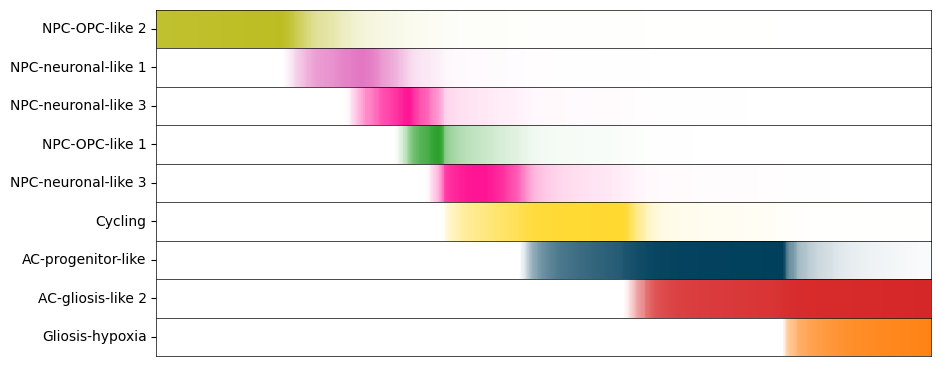

In [ ]:
df = TR_mu[clone].sort_index()

anno_df = annotation_df[annotation_df['clone']==clone].sort_values('module')
clone_annotation = {}
for k in anno_df['module']:
    clone_annotation[k] = anno_df.loc[anno_df["module"] == k]['annotation'].item()

fig, ax = plt.subplots(
    nrows=len(df.columns),
    ncols=1,
    figsize=(10, 0.5*len(df.columns)),
    gridspec_kw={"hspace": 0}
)

col_annotation = []
for m in df.columns:
    dfp = df[[m]].sort_index().T
    dfp.index = [clone_annotation[m]]

    sns.heatmap(
        dfp,
        cmap=MM_cmaps[clone_annotation[m]],
        ax = ax[int(m)],
        cbar=False
    )
    ax[int(m)].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    ax[int(m)].tick_params(axis='y', labelrotation=0)
    col_annotation.append(clone_annotation[m])

for i in ax.flat:
    for spine in i.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
        spine.set_color("black")

#plt.savefig(os.path.join(outdir, '{}_module_activation.pdf'.format(clone)))

In [ ]:
df.columns = [str(i)+': '+m for i,m in enumerate(col_annotation)]
df.to_csv('../../../data/EDFig8/EDFig8c1.csv')

## Genes

In [ ]:
df_mu = TR_mu[clone].sort_index()
df_g = TR_gene[clone].set_index('time').sort_index()

corr_dict = {}
for m in df_mu.columns:
    m_activation = df_mu[m]
    corr = df_g.corrwith(m_activation, method="pearson")
    corr_dict[m] = corr.sort_values(ascending=False).head(30)

In [ ]:
genes = {
"SYN3":"NPC-OPC-like 2",
"MYT1L":"NPC-neuronal-like 1",
"CUX2":"NPC-neuronal-like 1",
"CA8":"NPC-neuronal-like 3",
"BCAS1":"NPC-OPC-like 1",
"MYRFL":"NPC-OPC-like 1",
"CEMIP2":"NPC-neuronal-like 3",
"MKI67":"Cycling",
"RYR3":"AC-progenitor-like",
"GFAP":"AC-progenitor-like", # EGFR
"SERPINA3":"AC-gliosis-like 2",
"SERPINE1":"Gliosis-hypoxia",
"HILPDA":"Gliosis-hypoxia"
}

In [ ]:
df_g_plot = df_g[genes]

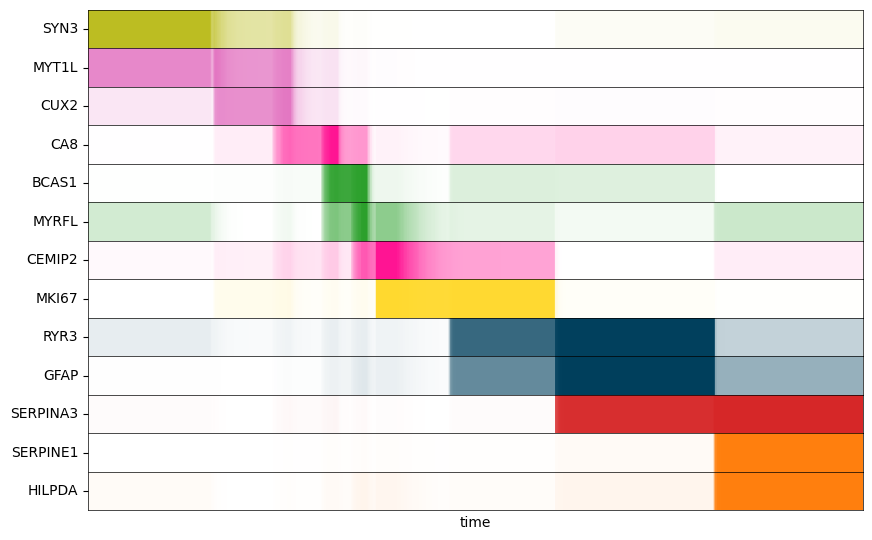

In [ ]:
fig, ax = plt.subplots(
    nrows=len(df_g_plot.columns),
    ncols=1,
    figsize=(10, 0.5*len(df_g_plot.columns)),
    gridspec_kw={"hspace": 0}
)

for i, g in enumerate(df_g_plot.columns):
    dfp = df_g[[g]].sort_index().T

    sns.heatmap(
        dfp,
        cmap=MM_cmaps[genes[g]],
        ax = ax[i],
        cbar=False
    )
    ax[i].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    ax[i].tick_params(axis='y', labelrotation=0)

for i in ax.flat:
    for spine in i.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
        spine.set_color("black")

plt.savefig(os.path.join(outdir, '{}_gene_activation.pdf'.format(clone)))

In [ ]:
df_g_plot.to_csv('../../../data/EDFig8/EDFig8c2.csv')

# Gene activation summarised across selected clones

In [ ]:
TR_gene_all = []
for clone in TR_gene:
    df = TR_gene[clone]
    df_scaled = (df - df.min()) / (df.max() - df.min())
    
    TR_gene_all.append(df_scaled)
TR_gene_all = pd.concat(TR_gene_all)

In [ ]:
early = ['DLL3', 
         'SOX10', 
         'MYT1'
        ]
mid = ['MYBL2', 
       'ASCL1', 
       'E2F1']
late = ['ETV6', 
        'FOS', 
        'HIF3A']

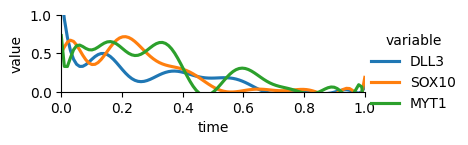

In [ ]:
df = TR_gene_all[early+['time']].melt(id_vars = 'time').dropna()

sns.lmplot(
    data=df,
    x="time",
    y="value",
    hue="variable",
    #lowess=True,        # smoothing
    scatter=False,      # <- no points
    ci=None,            # no CI band (optional)
    order = 15,
    height=1.5,
    aspect=2.5
)
plt.xlim(0,1)
plt.ylim(0,1)
df.to_csv('../../../data/EDFig8/EDFig8d1.csv')
plt.savefig(os.path.join(outdir, 'subset_early_genes.pdf'))

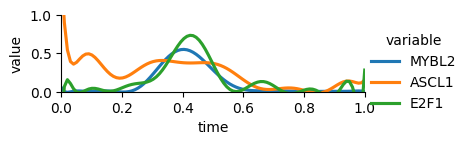

In [ ]:
df = TR_gene_all[mid+['time']].melt(id_vars = 'time').dropna()

sns.lmplot(
    data=df,
    x="time",
    y="value",
    hue="variable",
    #lowess=True,        # smoothing
    scatter=False,      # <- no points
    ci=None,            # no CI band (optional)
    order = 15,
    height=1.5,
    aspect=2.5
)
plt.xlim(0,1)
plt.ylim(0,1)
df.to_csv('../../../data/EDFig8/EDFig8d2.csv')
plt.savefig(os.path.join(outdir, 'subset_mid_genes.pdf'))

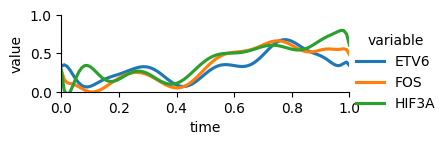

In [ ]:
df = TR_gene_all[late+['time']].melt(id_vars = 'time').dropna()

sns.lmplot(
    data=df,
    x="time",
    y="value",
    hue="variable",
    #lowess=True,        # smoothing
    scatter=False,      # <- no points
    ci=None,            # no CI band (optional)
    order = 15,
    height=1.5,
    aspect=2.5
)
plt.xlim(0,1)
plt.ylim(0,1)
df.to_csv('../../../data/EDFig8/EDFig8d3.csv')
plt.savefig(os.path.join(outdir, 'subset_late_genes.pdf'))